In [1]:
import numpy as np
from utils.data import load_data
import matplotlib.pyplot as plt

In [2]:
# ----- Load MNIST data -----

In [3]:
X_train, Y_train, X_test, Y_test = load_data()

idxs = np.arange(len(X_train))
np.random.shuffle(idxs)
split_idx = int(np.ceil(len(idxs)*0.8))
X_valid, Y_valid = X_train[idxs[split_idx:]], Y_train[idxs[split_idx:]]
X_train, Y_train = X_train[idxs[:split_idx]], Y_train[idxs[:split_idx]]

print() 
print('Set validation data aside')
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', Y_train.shape)
print('Validation data shape: ', X_valid.shape)
print('Validation labels shape: ', Y_valid.shape)

MNIST data loaded:
Training data shape: (60000, 784)
Training labels shape: (60000, 10)
Test data shape: (10000, 784)
Test labels shape: (10000, 10)

Set validation data aside
Training data shape:  (48000, 784)
Training labels shape:  (48000, 10)
Validation data shape:  (12000, 784)
Validation labels shape:  (12000, 10)


In [4]:
# ----- utils -----

In [5]:
def sigmoid(x, derivative=False):
    if derivative:
        return (np.exp(-x))/((np.exp(-x)+1)**2)
    return 1/(1 + np.exp(-x))


def softmax(x, derivative=False):
    # logit = np.exp(x)이 아닌 이유
    # : 만약 지나치게 큰 값이 원소로 들어가게 된다면, 값이 너무 커서 연산이 되지 않는 오버플로 문제를 일으킬 위험이 있음
    # softmax에 들어가는 원소들에 대하여, 그 원소들의 최댓값을 빼는 것으로 해결 가능!
    exps = np.exp(x - x.max())
    if derivative:
        return exps / np.sum(exps, axis=0) * (1 - exps / np.sum(exps, axis=0))
    return exps / np.sum(exps, axis=0)


def load_batch(X, Y, batch_size, shuffle=True):

    if shuffle:
        permutation = np.random.permutation(X.shape[0])
        X = X[permutation, :]
        Y = Y[permutation, :]
    
    num_steps = int(X.shape[0])//batch_size
    step = 0
    
    while step<num_steps:
        X_batch = X[batch_size*step:batch_size*(step+1)]
        Y_batch = Y[batch_size*step:batch_size*(step+1)]
        step+=1
        yield X_batch, Y_batch

In [6]:
# ----- 2-Layer Neural Network -----

In [7]:
class TwoLayerNN:

    def __init__(self, input_dim, num_hiddens, num_classes):
        
        self.input_dim = input_dim
        self.num_hiddens = num_hiddens
        self.num_classes = num_classes
        self.params = self.initialize_parameters(input_dim, num_hiddens, num_classes)

        
    def initialize_parameters(self, input_dim, num_hiddens, num_classes): # Xavier Initialization
        
        params = {}
        params["W1"] = np.random.randn(input_dim, num_hiddens)/ np.sqrt(input_dim) # (784, 64)
        params["b1"] = np.zeros(num_hiddens) # (64,)
        params["W2"] = np.random.randn(num_hiddens, num_classes)/ np.sqrt(num_hiddens) # (64, 10)
        params["b2"] = np.zeros(num_classes) # (10,)

        return params
    
    
    def forward(self, X): # y = softmax(sigmoid(X W1 + b1) W2 + b2)
        
        ff_dict = {}
        ff_dict['s1'] = np.matmul(X, self.params["W1"]) + self.params["b1"] # (256, 64)
        ff_dict['z'] = sigmoid(ff_dict['s1']) # (256, 64)
        ff_dict['s2'] = np.matmul(ff_dict['z'], self.params["W2"]) + self.params["b2"] # (256, 10)
        ff_dict['y'] = softmax(ff_dict['s2']) # (256, 10)
        y = ff_dict['y']
        
        return y, ff_dict

    
    def backward(self, X, Y, ff_dict):
        """
        y = softmax(sigmoid(X*W1 + b1) W2 + b2)
        
        s1 = X*W1 + b1
        z = sigmoid(s1)
        s2 = z*W2 + b2
        y = softmax(s2)
        
        dLdw2 = dLdy * dyds2 * ds2dw2 =  2(y-y_true) *  so'(z2)' * z = error_y * z 
        dLdb2 = dLdy * dyds2 * ds2db2 =  2(y-y_true) *  so'(z2)' * 1 = error_y * 1
        dLdw1 = dLdy * dyds2 * ds2dz * dzds1 * ds1dw1 = 2(y-y_true) *  so'(z2)' * w2 * z(1-z) * x = error_z * x
        dLdb1 = dLdy * dyds2 * ds2dz * dzds1 * ds1db1 = 2(y-y_true) *  so'(z2)' * w2 * z(1-z) * 1 = error_z * 1
        
        error_y = 2(y-y_true) *  so'(z2)'
        error_z = error_y * w2 * z(1-z) 
        """
        error_y = 2*(ff_dict['y']-Y) * softmax(ff_dict['s2'], derivative=True) # (256, 10) * (256, 10) = (256, 10)
        error_z = error_y.dot(self.params['W2'].T) * sigmoid(ff_dict['z'], derivative=True) # ((256, 10) * (10, 64)) * (256, 64) * (256, 64) = (256, 64)

        grads = {}
        grads["dW2"] = np.matmul(ff_dict['z'].T, error_y) # (64, 256) * (256, 10) = (64, 10)
        grads["db2"] = np.sum(error_y,axis=0)*(-1.) # (256, 10)을 열 방향으로 합치면 (10,)
        grads["dW1"] = np.matmul(X.T, error_z) # (784, 256) * (256, 64) = (784, 64)
        grads["db1"] = np.sum(error_z,axis=0)*(-1.) # (256, 64)을 열 방향으로 합치면 (64,)

        return grads
    
    
    def compute_loss(self, Y, Y_hat): # cross entropy loss
        
        loss = -(1/Y.shape[0]) * np.sum(np.multiply(Y, np.log(Y_hat)))
        return loss
    
    
    def train(self, X, Y, X_val, Y_val, lr, n_epochs, batch_size, log_interval=1):

        epoch_dat = []
        train_acc_dat = []
        valid_acc_dat = []
        
        for epoch in range(n_epochs):
            
            for X_batch, Y_batch in load_batch(X, Y, batch_size):
                self.train_step(X_batch, Y_batch, batch_size, lr)
            
            if epoch % log_interval == 0:
                Y_hat, ff_dict = self.forward(X)
                train_loss = self.compute_loss(Y, Y_hat)
                train_acc = self.evaluate(Y, Y_hat)
                Y_hat, ff_dict = self.forward(X_val)
                valid_loss = self.compute_loss(Y_val, Y_hat)
                valid_acc = self.evaluate(Y_val, Y_hat)
                
                epoch_dat.append(epoch)
                train_acc_dat.append(train_acc)
                valid_acc_dat.append(valid_acc)  
                
                if epoch % 10 == 0:
                    print('epoch {:02} - train loss/acc: {:.3f} {:.3f}, valid loss/acc: {:.3f} {:.3f}'.\
                          format(epoch, train_loss, train_acc, valid_loss, valid_acc))

        plt.plot(epoch_dat, train_acc_dat, '-*')
        plt.plot(epoch_dat, valid_acc_dat, '-*')
        plt.show()
                    
    # Updates the parameters using gradient descent
    def train_step(self, X_batch, Y_batch, batch_size, lr):
        
        _, ff_dict = self.forward(X_batch)
        grads = self.backward(X_batch, Y_batch, ff_dict)
        self.params["W1"] -= lr * grads["dW1"]/batch_size
        self.params["b1"] -= lr * grads["db1"]/batch_size
        self.params["W2"] -= lr * grads["dW2"]/batch_size
        self.params["b2"] -= lr * grads["db2"]/batch_size

        
    def evaluate(self, Y, Y_hat): # classification accuracy
     
        classes_pred = np.argmax(Y_hat, axis=1)
        classes_gt = np.argmax(Y, axis=1)
        accuracy = float(np.sum(classes_pred==classes_gt)) / Y.shape[0]
        
        return accuracy

In [8]:
# ----- Training & Evaluation -----

In [9]:
# model instantiation
model = TwoLayerNN(input_dim=784, num_hiddens=64, num_classes=10)

In [10]:
# 확인용
params = model.initialize_parameters(input_dim=784, num_hiddens=64, num_classes=10)
print('initialize_parameters')
print('W1', params['W1'].shape)
print("b1", params["b1"].shape)
print("W2", params["W2"].shape)
print("b2", params["b2"].shape)
print(' ')

X = X_train[:256]
Y = Y_train[:256]
print('input')
print('X: ',X.shape, 'Y: ', Y.shape)
print(' ')

y, ff_dict = model.forward(X)
print('forward')
print('s1', ff_dict['s1'].shape)
print('z', ff_dict['z'].shape)
print('s2', ff_dict['s2'].shape)
print('y', ff_dict['y'].shape)
print(' ')

grads = model.backward(X, Y, ff_dict)
print('backward')
print('dW1', grads['dW1'].shape)
print("db1", grads["db1"].shape)
print("dW2", grads["dW2"].shape)
print("db2", grads["db2"].shape)

initialize_parameters
W1 (784, 64)
b1 (64,)
W2 (64, 10)
b2 (10,)
 
input
X:  (256, 784) Y:  (256, 10)
 
forward
s1 (256, 64)
z (256, 64)
s2 (256, 10)
y (256, 10)
 
backward
dW1 (784, 64)
db1 (64,)
dW2 (64, 10)
db2 (10,)


In [11]:
# ----- Training & Evaluation -----

In [19]:
# model instantiation
model = TwoLayerNN(input_dim=784, num_hiddens=64, num_classes=10)

epoch 00 - train loss/acc: 10.775 0.131, valid loss/acc: 9.388 0.137
epoch 10 - train loss/acc: 10.718 0.443, valid loss/acc: 9.332 0.440
epoch 20 - train loss/acc: 10.809 0.496, valid loss/acc: 9.425 0.489
epoch 30 - train loss/acc: 10.787 0.419, valid loss/acc: 9.402 0.408
epoch 40 - train loss/acc: 10.771 0.302, valid loss/acc: 9.384 0.303
epoch 50 - train loss/acc: 10.774 0.184, valid loss/acc: 9.388 0.189
epoch 60 - train loss/acc: 10.778 0.125, valid loss/acc: 9.392 0.125
epoch 70 - train loss/acc: 10.779 0.111, valid loss/acc: 9.393 0.112
epoch 80 - train loss/acc: 10.779 0.104, valid loss/acc: 9.393 0.106
epoch 90 - train loss/acc: 10.779 0.101, valid loss/acc: 9.393 0.101
epoch 100 - train loss/acc: 10.779 0.099, valid loss/acc: 9.393 0.100
epoch 110 - train loss/acc: 10.779 0.098, valid loss/acc: 9.393 0.099
epoch 120 - train loss/acc: 10.779 0.098, valid loss/acc: 9.393 0.098
epoch 130 - train loss/acc: 10.779 0.098, valid loss/acc: 9.393 0.098
epoch 140 - train loss/acc: 10

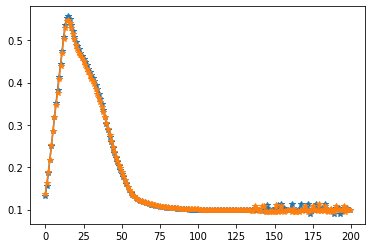

In [20]:
# train the model
lr, n_epochs, batch_size = 0.1, 200, 256
model.train(X_train, Y_train, X_valid, Y_valid, lr, n_epochs, batch_size)